# Paintshop Color Change Scheduling with FICO Xpress
[![color_change_scheduling.ipynb](https://img.shields.io/badge/github-%23121011.svg?logo=github)](https://github.com/ampl/colab.ampl.com/blob/master/authors/glebbelov/scheduling/color_change/color_change_scheduling.ipynb) [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ampl/colab.ampl.com/blob/master/authors/glebbelov/scheduling/color_change/color_change_scheduling.ipynb) [![Open In Deepnote](https://deepnote.com/buttons/launch-in-deepnote-small.svg)](https://deepnote.com/launch?url=https://github.com/ampl/colab.ampl.com/blob/master/authors/glebbelov/scheduling/color_change/color_change_scheduling.ipynb) [![Open In Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://github.com/ampl/colab.ampl.com/blob/master/authors/glebbelov/scheduling/color_change/color_change_scheduling.ipynb) [![Open In Gradient](https://assets.paperspace.io/img/gradient-badge.svg)](https://console.paperspace.com/github/ampl/colab.ampl.com/blob/master/authors/glebbelov/scheduling/color_change/color_change_scheduling.ipynb) [![Open In SageMaker Studio Lab](https://studiolab.sagemaker.aws/studiolab.svg)](https://studiolab.sagemaker.aws/import/github/ampl/colab.ampl.com/blob/master/authors/glebbelov/scheduling/color_change/color_change_scheduling.ipynb) [![Powered by AMPL](https://h.ampl.com/https://github.com/ampl/colab.ampl.com/blob/master/authors/glebbelov/scheduling/color_change/color_change_scheduling.ipynb)](https://ampl.com)

Description: A scheduling problem demonstrating high-level modeling and automatic solver tuning in FICO Xpress

Tags: AMPLPY, MP, scheduling, color change scheduling, tuning, xpress

Notebook author: Gleb Belov <<gleb@ampl.com>>

Reference:

1. F. Winter and N. Musliu (2022). A large neighborhood search approach for the paint shop scheduling problem. *J Sched* 25 pp 453-475.
2. AMPL Xpress documentation. [https://dev.ampl.com/solvers/xpress/index.html](https://dev.ampl.com/solvers/xpress/index.html).
3. AMPL MP Library: modeling guide. [https://mp.ampl.com/](https://mp.ampl.com/).

In [1]:
# Install dependencies
%pip install -q amplpy pandas

In [2]:
# Google Colab & Kaggle integration
from amplpy import AMPL, ampl_notebook

ampl = ampl_notebook(
    modules=["xpress"],  # modules to install
    license_uuid="default",  # license to use
)  # instantiate AMPL object and register magics

## Problem description

*Paintshop color change scheduling problem (PCCSP)* is a subproblem in the *paintshop scheduling problem (PSSP)*. While PSSP optimizes a complete schedule, PCCSP is restricted to decisions concerning coloring operations.

Given a predefined sequence of *skid types* passing through coloring equipment, PCCSP assigns car parts to the skids so that to minimize color change costs. While in practice the skid type sequence comes from a larger problem, we generate that and other parameters randomly.

We set up the model and apply FICO Xpress parameter tuning.

## Model highlights

* Pre-defined sequence of skid types
* Each skid type can hold one of pre-defined combinations (*patterns*) of car parts.
  * For example, skid type 926 can hold one of the patterns 20, 35, ...
* Each pattern has
  *  *minimal* and *extra* demands (how many times it should be scheduled);
  * Several color specifications:
    * Two "simple" colors (can be quickly changed between skids)
    * "Maximal" color, if any (change requires 30 skids' waiting time, however there are three Max coloring machines)
* Minimize costs for over- and underproduction, as well as color change costs of each specification.

## AMPL model

Use `%%writefile` to save AMPL model, or `%%ampl_eval` to evaluate AMPL statements

In [3]:
%%writefile pccsp.mod

set SKID_TYPES;                          # Parameter sets
set PATTERNS;
set COLOR_SIMPLE_CATEGORIES;
set COLORS_SIMPLE {COLOR_SIMPLE_CATEGORIES};
set COLORS_MAX;
set COLOR_MAX_MACHINES default 1..3;

param n_slots;                           # Allocation parameters
set SLOTS := 1..n_slots;
param slot_skid_type {SLOTS} in SKID_TYPES;
set SKID_TYPE_PATTERNS {SKID_TYPES} within PATTERNS;
param pattern_demand_minimum {PATTERNS};
param pattern_demand_extra {PATTERNS};

                                         # Color parameters
param color_spec_simple {PATTERNS, cc in COLOR_SIMPLE_CATEGORIES}
        in COLORS_SIMPLE[cc];
param color_spec_MAX {PATTERNS} in COLORS_MAX union {0};   # 0 means not used
param wait_change_MAX integer default 30;  # For each MAX machine

                                         # Costs
param pattern_missing_cost {PATTERNS};
param pattern_overuse_cost {PATTERNS};
param color_simple_change_cost {COLOR_SIMPLE_CATEGORIES};
param color_MAX_change_cost;


# Primary variables
var slot_pattern {SLOTS} in PATTERNS union {0};  # 0 means slot empty
var slot_color_spec_MAX {SLOTS, COLOR_MAX_MACHINES} in COLORS_MAX;
var slot_color_MAX_machine_available {SLOTS, COLOR_MAX_MACHINES} binary;

# Secondary variables
var pattern_use {p in PATTERNS} >= pattern_demand_minimum[p];
var pattern_missing {p in PATTERNS} >= 0;
var pattern_overuse {p in PATTERNS} >= 0;
var slot_color_spec {SLOTS, cc in COLOR_SIMPLE_CATEGORIES} in COLORS_SIMPLE[cc];
var slot_color_change {1..n_slots-1, COLOR_SIMPLE_CATEGORIES} binary;
var slot_color_MAX_change {1..n_slots-1, COLOR_MAX_MACHINES} binary;

# Constraints
s.t. PatternUse {p in PATTERNS}:
    pattern_use[p] ==
        count {s in SLOTS} (p == slot_pattern[s]);

s.t. PatternUseBalance {p in PATTERNS}:
    pattern_demand_minimum[p] + pattern_demand_extra[p] +
        pattern_overuse[p] ==
        pattern_use[p] + pattern_missing[p];

s.t. PatternChoice {s in SLOTS}:                # Restrict pattern choice in the slot
    exists {p in {0} union SKID_TYPE_PATTERNS[slot_skid_type[s]]}
        (p == slot_pattern[s]);

s.t. ColorSimpleSpec {s in SLOTS,
                      p in SKID_TYPE_PATTERNS[slot_skid_type[s]],
                     cc in COLOR_SIMPLE_CATEGORIES}:
    (p == slot_pattern[s]) ==>                  # Pattern p selected ==>
        (slot_color_spec[s, cc] == color_spec_simple[p, cc]);  # Assign simple colors

s.t. ColorSimpleChanges {s in 1..n_slots-1,
                         cc in COLOR_SIMPLE_CATEGORIES}:
    (slot_color_spec[s, cc] != slot_color_spec[s+1, cc]) ==> slot_color_change[s, cc];

s.t. ColorMAXSpec {s in SLOTS,
                   p in SKID_TYPE_PATTERNS[slot_skid_type[s]]:
                   color_spec_MAX[p] in COLORS_MAX}:   # If p requires some color MAX:
    (p == slot_pattern[s]) ==>                  # Pattern allocated ==>
        (exists {cm in COLOR_MAX_MACHINES}      # some MAX machine must do it
            (slot_color_spec_MAX[s, cm] == color_spec_MAX[p]
                && slot_color_MAX_machine_available[s, cm]));

s.t. ColorMAXChanges {s in 1..n_slots-1,
                      cm in COLOR_MAX_MACHINES}:# Changing MAX color on machine cm ==>
    (slot_color_spec_MAX[s, cm] != slot_color_spec_MAX[s+1, cm]) ==>
        ((forall {s1 in s+1..min(n_slots, s+wait_change_MAX)}
            ! slot_color_MAX_machine_available[s1, cm])  # Block cm for 30 slots
         && slot_color_MAX_change[s, cm]);      # and bump change flag


# Objective
minimize TotalCosts:
    sum {p in PATTERNS} (pattern_missing_cost[p] * pattern_missing[p]
                         + pattern_overuse_cost[p] * pattern_overuse[p])
    + sum {s in 1.. n_slots-1}
          (sum {cc in COLOR_SIMPLE_CATEGORIES}
               color_simple_change_cost[cc] * slot_color_change[s, cc]
           + sum {cm in COLOR_MAX_MACHINES}
               color_MAX_change_cost * slot_color_MAX_change[s, cm]);

Overwriting pccsp.mod


## Instance generation code

In [4]:
import random
import math
from dataclasses import dataclass, field
from typing import List, Set, Dict


class InstGenParams:
    def __init__(self):
        self.nSkidTypes = 4
        self.nPatterns = 5
        self.nSlots = 50

        self.nSkidTypesForPatternMeanDev = [1, 2]  # Dev is variance
        self.dSkidTypeNWindowsMeanDev = [3, 10]
        self.demandMinMeanDev = [1, 4]
        self.demandExtraMeanDev = [10, 40]

        self.nColorsSimple = [4, 5]                # N colors for each simple category
        self.nColorsMax = 7
        self.pUsingColorMax = 0.7                 # Probability for a pattern
        self.nColorMAXMachines = 3
        self.nChangeMAXWait = 30

        self.minCost = 1e-3                     # For a cost
        self.patternMissingCostMeanDev = [10, 5]
        self.patternOveruseCostMeanDev = [2, 1]
        self.colorSimpleChangeCost = [1, 1]     # For each category
        self.colorMAXChangeCost = [10]

        
# -------------------- Data Model --------------------

@dataclass
class PatternData:
    id: int
    min_demand: int = 0
    extra_demand: int = 0
    allowable_skid_types: Set[int] = field(default_factory=set)
    total_assigned: int = 0


@dataclass
class SkidTypeData:
    id: int
    allowable_patterns: Set[int] = field(default_factory=set)
    total_usage: int = 0
    n_subsequences: int = 0
    n_subseq_merged: int = 0      # Some can be consecutive
    subsequences: List[int] = field(default_factory=list)  # sizes of each block
    subseq_merged: List[int] = field(default_factory=list)  # sizes of each block


@dataclass
class InstanceResult:
    skid_types: Dict[int, SkidTypeData]
    patterns: Dict[int, PatternData]
    skid_type_usages: List[int]
    sum_min_demands: int
    pattern_min_demands: List[int]
    pattern_extra_demands: List[int]
    overall_sequence: List[int]

    color_spec_simple: List[int]
    color_spec_MAX: List[int]
    nColorMAXMachines: int
    nChangeMAXWait: int

    patternMissingCost: List[int]
    patternOveruseCost: List[int]
    colorSimpleChangeCost: List[int]
    colorMAXChangeCost: int

# -------------------- Generator --------------------

class InstanceGenerator:

    def __init__(self, params: InstGenParams, seed: int = 42):
        self.params = params
        if seed is not None:
            random.seed(seed)

        self.patterns = {i: PatternData(i) for i in range(params.nPatterns)}
        self.skid_types = {i: SkidTypeData(i) for i in range(params.nSkidTypes)}
        self.total_used_skids = 0

    # --------- Utility Draw Methods ---------

    @staticmethod
    def _draw_nonnegative_int(mean_dev):
        """Gaussian draw, rounded to integer, truncated at 0."""
        mean, dev = mean_dev
        return max(0, int(round(random.gauss(mean, math.sqrt(dev)))))

    @staticmethod
    def _draw_positive_int(mean_dev):
        """Gaussian draw truncated at 1."""
        return max(1, InstanceGenerator._draw_nonnegative_int(mean_dev))

    # --------- Step 1 ---------

    def generate_pattern_demands(self):
        """
        1. For each pattern, generate minimal and extra demand.
           Negative draws are replaced by 0.
        """
        for p in self.patterns.values():
            p.min_demand = self._draw_nonnegative_int(
                self.params.demandMinMeanDev
            )
            p.extra_demand = self._draw_nonnegative_int(
                self.params.demandExtraMeanDev
            )

    # --------- Step 2 ---------

    def generate_allowable_sets(self):
        """
        2. For each pattern, generate allowable skid types.
           Cardinality drawn from mean/deviation.
           Also build inverse mapping: skid_type -> allowable patterns.
        """
        for p in self.patterns.values():
            k = self._draw_nonnegative_int(
                self.params.nSkidTypesForPatternMeanDev
            )

            # At least 1, at most total skid types
            k = min(max(1, k), self.params.nSkidTypes)

            allowable = set(random.sample(range(self.params.nSkidTypes), k))
            p.allowable_skid_types = allowable

            for s in allowable:
                self.skid_types[s].allowable_patterns.add(p.id)

    # --------- Step 3 & 4 ---------

    def assign_min_demands(self):
        """
        3. Assign each pattern to min_demand skids from its allowable set.
        4. If total usage exceeds nSlots → error.
        """
        for p in self.patterns.values():
            for _ in range(p.min_demand):
                skid = random.choice(list(p.allowable_skid_types))
                self._assign(p.id, skid)

        if self.total_used_skids > self.params.nSlots:
            raise ValueError("Minimal demands exceed total number of slots")

    # --------- Step 5 & 6 ---------

    def fill_remaining_slots(self):
        """
        5. total_used_skids already maintained.
        6. While below nSlots, repeatedly assign:
           - pattern chosen with probability proportional to extra_demand + 1
           - skid chosen uniformly from pattern's allowable set
        """
        while self.total_used_skids < self.params.nSlots:
            weights = [
                self.patterns[i].extra_demand + 1
                for i in self.patterns
            ]

            pattern_id = random.choices(
                population=list(self.patterns.keys()),
                weights=weights,
                k=1
            )[0]

            skid = random.choice(
                list(self.patterns[pattern_id].allowable_skid_types)
            )

            self._assign(pattern_id, skid)

    def _assign(self, pattern_id: int, skid_id: int):
        """Internal consistent assignment update."""
        self.patterns[pattern_id].total_assigned += 1
        self.skid_types[skid_id].total_usage += 1
        self.total_used_skids += 1

    # --------- Step 7 & 8 ---------

    def generate_subsequences(self):
        """
        7. For each used skid type:
           - draw number of subsequences (>=1)
           - may exceed number of allowable patterns
           - cap only by total usage
        8. Split total usage into that many positive parts.
        """
        for s in self.skid_types.values():

            if s.total_usage == 0:
                continue

            # subsequence count may exceed allowable patterns
            n = self._draw_positive_int(
                self.params.dSkidTypeNWindowsMeanDev
            )

            # Cannot exceed total usage (must allow positive split)
            n = min(n, s.total_usage)

            s.n_subsequences = n

            # Random composition of total_usage into n positive integers
            if n == 1:
                s.subsequences = [s.total_usage]
                continue

            cuts = sorted(random.sample(
                range(1, s.total_usage), n - 1
            ))

            parts = []
            prev = 0
            for c in cuts + [s.total_usage]:
                parts.append(c - prev)
                prev = c

            s.subsequences = parts

    # --------- Step 9 ---------

    def build_overall_sequence(self) -> List[int]:
        """
        9. Build sequence by shuffling whole subsequences (blocks),
           not individual skid units.
        """
        blocks = []

        for s in self.skid_types.values():
            for size in s.subsequences:
                # Each block is a contiguous identical skid type
                blocks.append([s.id] * size)

        # Shuffle blocks (not flattened list)
        random.shuffle(blocks)

        # Flatten blocks preserving block integrity
        sequence = [x for block in blocks for x in block]

        # Safety check
        if len(sequence) != self.params.nSlots:
            raise RuntimeError("Final sequence length mismatch")

        return sequence

    # --------- Step 10 ---------
    def generate_colors(self):
        self.color_spec_simple = [ [] for cc in self.params.nColorsSimple ]
        self.color_spec_MAX = []
        for s in self.patterns.values():
            if (random.random() < self.params.pUsingColorMax):   # All int's to add +1
                self.color_spec_MAX.append( random.randint(0, self.params.nColorsMax-1) )
            else:
                self.color_spec_MAX.append( -1 )        # No using color MAX
            for cc in range(len(self.params.nColorsSimple)):
                self.color_spec_simple[cc].append(
                     random.randint(0, self.params.nColorsSimple[cc]-1) 
                )

    # --------- Step 11 ---------
    def generate_costs(self):
        self.pattern_missing_cost = []
        self.pattern_overuse_cost = []
        mm, md = self.params.patternMissingCostMeanDev
        om, od = self.params.patternOveruseCostMeanDev
        for s in self.patterns.values():
            self.pattern_missing_cost.append(
                max(self.params.minCost, random.gauss(mm, math.sqrt(md))) )
            self.pattern_overuse_cost.append(
                max(self.params.minCost, random.gauss(om, math.sqrt(od))) )

    # --------- Step 12 ---------

    def generate(self) -> InstanceResult:
        """
        Full generation pipeline following steps 1–10.
        """
        self.generate_pattern_demands()
        self.generate_allowable_sets()
        self.assign_min_demands()
        self.fill_remaining_slots()
        self.generate_subsequences()
        sequence = self.build_overall_sequence()

        self.generate_colors()
        self.generate_costs()

        return InstanceResult(
            skid_types=self.skid_types,
            patterns=self.patterns,
            skid_type_usages=[
                self.skid_types[i].total_usage
                for i in range(self.params.nSkidTypes)
            ],
            sum_min_demands=sum(
                p.min_demand for p in self.patterns.values()
            ),
            pattern_min_demands=[
                p.min_demand for p in self.patterns.values()
            ],
            pattern_extra_demands=[
                p.extra_demand for p in self.patterns.values()
            ],
            overall_sequence=sequence,

            color_spec_simple = self.color_spec_simple,
            color_spec_MAX = self.color_spec_MAX,
            nColorMAXMachines = self.params.nColorMAXMachines,
            nChangeMAXWait = self.params.nChangeMAXWait,

            patternMissingCost = self.pattern_missing_cost,
            patternOveruseCost = self.pattern_overuse_cost,
            colorSimpleChangeCost = self.params.colorSimpleChangeCost,
            colorMAXChangeCost = self.params.colorMAXChangeCost
        )

## Pretty-printing and visualization code

In [5]:
import pandas as pd
from typing import Optional


def display_instance(result: InstanceResult,
                     params: InstGenParams,
                     max_sequence_display: int = 100,
                     show_empty_skids: bool = False) -> None:
    """
    Pretty-print instance data for Jupyter Notebook usage.

    Parameters
    ----------
    result : InstanceResult
    params : InstGenParams
    max_sequence_display : int
        Maximum number of sequence entries to display.
    show_empty_skids : bool
        If False, hide skid types with zero usage.
    """

    print("========== INSTANCE SUMMARY ==========")
    print(f"Patterns          : {params.nPatterns}")
    print(f"Skid types        : {params.nSkidTypes}")
    print(f"Slots             : {params.nSlots}")
    print(f"Sum minimal demand: {result.sum_min_demands}")
    print(f"Total usage       : {sum(result.skid_type_usages)}")
    print()

    # ---------------- Patterns ----------------

    pattern_rows = []
    for p in result.patterns.values():
        pattern_rows.append({
            "Pattern": p.id,
            "MinDemand": p.min_demand,
            "ExtraDemand": p.extra_demand,
            "TotalAssigned": p.total_assigned,
            "AllowableSkids": sorted(list(p.allowable_skid_types))
        })

    df_patterns = pd.DataFrame(pattern_rows)
    print("---------- PATTERNS ----------")
    display(df_patterns.sort_values("Pattern").reset_index(drop=True))
    print()

    # ---------------- Skid Types ----------------

    skid_rows = []
    for s in result.skid_types.values():
        if not show_empty_skids and s.total_usage == 0:
            continue

        skid_rows.append({
            "SkidType": s.id,
            "TotalUsage": s.total_usage,
            "N_Subseq": s.n_subsequences,
            "SubseqSizes": s.subsequences,
            "AllowablePatterns": sorted(list(s.allowable_patterns))
        })

    df_skids = pd.DataFrame(skid_rows)
    print("---------- SKID TYPES (showing non-merged subsequence sizes) ----------")
    if not df_skids.empty:
        display(df_skids.sort_values("SkidType").reset_index(drop=True))
    else:
        print("(No used skid types)")
    print()

    # ---------------- Overall Sequence ----------------

    print("---------- OVERALL SEQUENCE (some subsequences can be merged) ----------")
    print(f"Length: {len(result.overall_sequence)}")

    s = 0
    i_subseq = 0
    while s < len(result.overall_sequence):
        l_subseq = 1
        s_next = s+1
        while s_next < len(result.overall_sequence) and \
            result.overall_sequence[s_next] == result.overall_sequence[s]:
            l_subseq += 1
            s_next += 1
        print("{}:   Skid type x multiplicity: {} x {}".format(
            i_subseq, result.overall_sequence[s], l_subseq))
        result.skid_types[result.overall_sequence[s]].n_subseq_merged += 1
        result.skid_types[result.overall_sequence[s]].subseq_merged. append(l_subseq)
        s = s_next
        i_subseq += 1
            
    print("======================================")

In [6]:
import matplotlib.pyplot as plt


def visualize_instance_statistics(result: InstanceResult,
                                   show_empty_skids: bool = False) -> None:
    """
    Visualize key structural statistics of the generated instance.

    Produces three separate histograms:
      1) Skid type total usage
      2) Subsequence sizes (block lengths)
      3) Number of subsequences per skid type

    Parameters
    ----------
    result : InstanceResult
    show_empty_skids : bool
        If False, exclude skid types with zero usage.
    """

    # -------------------------
    # Collect data
    # -------------------------

    skid_types_with_usage = []
    skid_types_non0 = []
    usages = []
    n_subseq = []
    subseq_sizes = []

    for s in result.skid_types.values():

        if not show_empty_skids and s.total_usage == 0:
            continue

        skid_types_with_usage.append(s.id)
        usages.append(s.total_usage)

        if s.total_usage > 0:
            skid_types_non0.append(s.id)
            n_subseq.append(s.n_subseq_merged)
            subseq_sizes.extend(s.subseq_merged)

    # -------------------------
    # 1. Histogram: Skid Usage
    # -------------------------

    print("Create usage histogram: usages", usages)
    
    plt.figure()
    plt.bar(skid_types_with_usage, usages, color='green')
    plt.title("Histogram of Skid Type Total Usage")
    plt.xlabel("Skid type")
    plt.ylabel("Usage")
    # plt.set_xticks(skid_types_with_usage)
    plt.show()

    # -------------------------
    # 2. Histogram: Subsequence Sizes
    # -------------------------

    if subseq_sizes:
        plt.figure()
        plt.hist(subseq_sizes, max(subseq_sizes), color='red')
        plt.title("Histogram of Subsequence Sizes")
        plt.xlabel("Subsequence Size (block length)")
        plt.ylabel("Frequency")
        plt.show()
    else:
        print("No subsequences to display.")

    # -------------------------
    # 3. Histogram: Number of Subsequences per Skid
    # -------------------------

    if n_subseq:
        plt.figure()
        plt.bar(skid_types_non0, n_subseq)
        plt.title("Histogram of Number of Subsequences per Skid Type")
        plt.ylabel("Number of Subsequences")
        plt.xlabel("Skid type")
        plt.show()
    else:
        print("No subsequence-count data to display.")

## Generate & visualize data

In [7]:
params = InstGenParams()
generator = InstanceGenerator(params)

instance = generator.generate()

In [8]:
display_instance(instance, params)

========== INSTANCE SUMMARY ==========
Patterns          : 5
Skid types        : 4
Slots             : 50
Sum minimal demand: 6
Total usage       : 50

---------- PATTERNS ----------


,Pattern,MinDemand,ExtraDemand,TotalAssigned,AllowableSkids
0,0,1,9,9,[0]
1,1,1,14,12,"[1, 2, 3]"
2,2,1,1,2,[0]
3,3,2,8,15,"[1, 2, 3]"
4,4,1,11,12,[2]



---------- SKID TYPES (showing non-merged subsequence sizes) ----------


,SkidType,TotalUsage,N_Subseq,SubseqSizes,AllowablePatterns
0,0,11,5,"[2, 1, 4, 2, 2]","[0, 2]"
1,1,10,1,[10],"[1, 3]"
2,2,22,1,[22],"[1, 3, 4]"
3,3,7,1,[7],"[1, 3]"



---------- OVERALL SEQUENCE (some subsequences can be merged) ----------
Length: 50
0:   Skid type x multiplicity: 0 x 2
1:   Skid type x multiplicity: 3 x 7
2:   Skid type x multiplicity: 0 x 9
3:   Skid type x multiplicity: 2 x 22
4:   Skid type x multiplicity: 1 x 10


Create usage histogram: usages [11, 10, 22, 7]


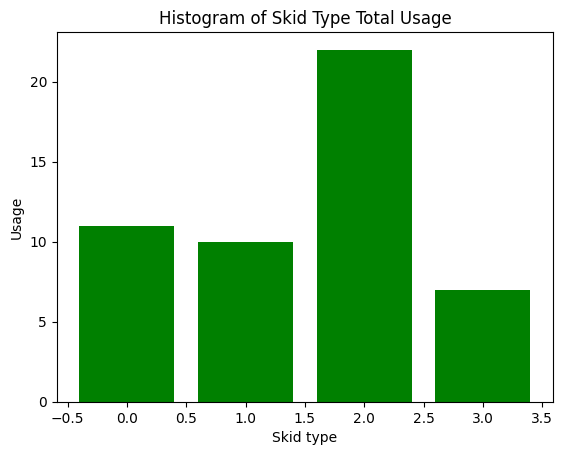

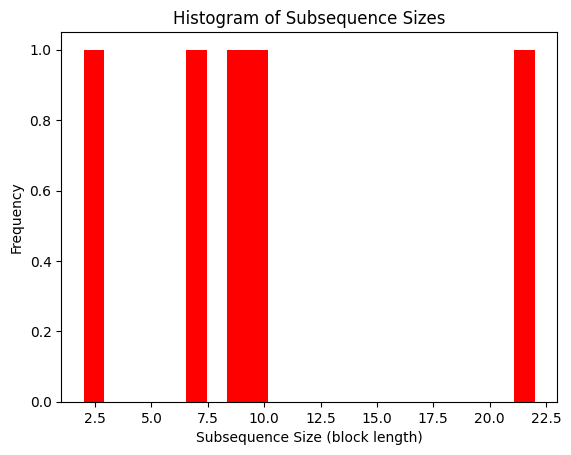

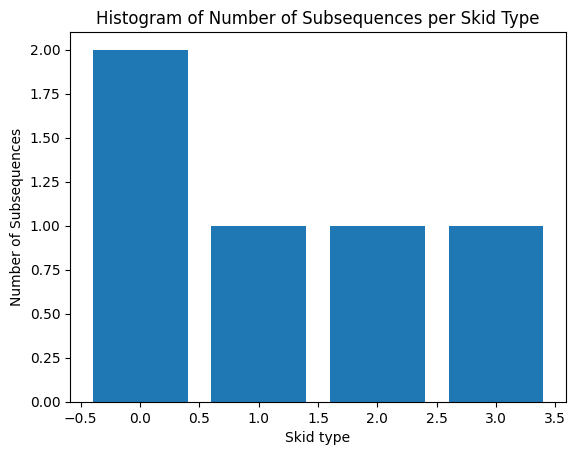

In [9]:
visualize_instance_statistics(instance, True)

## Load data directly from Python data structures using [amplpy](https://amplpy.readthedocs.io/)

In [10]:
import numpy as np
import pandas as pd


def load_instance_into_ampl_vectorized_1based(ampl: AMPL,
                                              result: InstanceResult,
                                              params: InstGenParams) -> None:
    """
    Vectorized AMPL loader with 0→1 index shifting
    for skid types and patterns.
    """

    # ------------------------------------------------
    # 1. Shifted SKID_TYPES and PATTERNS
    # ------------------------------------------------

    skid_ids = np.array(list(result.skid_types.keys()), dtype=int) + 1
    pattern_ids = np.array(list(result.patterns.keys()), dtype=int) + 1

    ampl.set["SKID_TYPES"] = skid_ids
    ampl.set["PATTERNS"] = pattern_ids

    # ------------------------------------------------
    # 2. Scalar parameter
    # ------------------------------------------------

    ampl.param["n_slots"] = params.nSlots

    # ------------------------------------------------
    # 3. Slot → Skid mapping (shift skid values)
    # ------------------------------------------------

    slot_df = pd.DataFrame({
        "SLOTS": np.arange(1, params.nSlots + 1),
        "slot_skid_type": np.array(result.overall_sequence, dtype=int) + 1
    }).set_index("SLOTS")

    ampl.setData(slot_df)

    # ------------------------------------------------
    # 4. SKID_TYPE_PATTERNS relation (shift both sides)
    # ------------------------------------------------

    rows = []

    for skid_id, skid in result.skid_types.items():
        skid_shifted = skid_id + 1
        patterns_shifted = np.array(list(skid.allowable_patterns), dtype=int) + 1
        ampl.set['SKID_TYPE_PATTERNS'][skid_shifted] = patterns_shifted

    # ------------------------------------------------
    # 5. Pattern demand parameters (shift index)
    # ------------------------------------------------

    demand_df = pd.DataFrame({
        "PATTERNS": pattern_ids,
        "pattern_demand_minimum": [
            p.min_demand for p in result.patterns.values()
        ],
        "pattern_demand_extra": [
            p.extra_demand for p in result.patterns.values()
        ]
    }).set_index("PATTERNS")

    ampl.setData(demand_df)

    # ------------------------------------------------
    # 6. Colors
    # ------------------------------------------------

    ampl.set['COLOR_SIMPLE_CATEGORIES'] = range(1, len(result.color_spec_simple)+1)
    ampl.set['COLORS_MAX'] = range(1, params.nColorsMax+1)
    ampl.set['COLOR_MAX_MACHINES'] = range(1, result.nColorMAXMachines+1)
    for cc in range(len(result.color_spec_simple)):
        ampl.set['COLORS_SIMPLE'][cc+1] = range(1, params.nColorsSimple[cc]+1)
        for p in range(len(result.patternMissingCost)):      # Rather slow
            ampl.param['color_spec_simple'][p+1, cc+1] = \
                result.color_spec_simple[cc][p] + 1
    ampl.param['color_spec_MAX'] = \
        np.array(list(result.color_spec_MAX), dtype=int) + 1
    ampl.param['wait_change_MAX'] = result.nChangeMAXWait

    # ------------------------------------------------
    # 6. Colors
    # ------------------------------------------------

    ampl.param['pattern_missing_cost'] = \
        np.array(list(result.patternMissingCost), dtype=float)
    ampl.param['pattern_overuse_cost'] = \
        np.array(list(result.patternOveruseCost), dtype=float)
    ampl.param['color_simple_change_cost'] = \
        np.array(list(result.colorSimpleChangeCost), dtype=float)
    ampl.param['color_MAX_change_cost'] = result.colorMAXChangeCost

In [11]:
ampl = AMPL()
ampl.read('pccsp.mod')

load_instance_into_ampl_vectorized_1based(ampl, instance, params)

## Solve with FICO Xpress

First, let us solve the instance with a time limit.

In [12]:
ampl.option["solver"] = "xpress"
ampl.option["mp_options"] = \
        "outlev=1 " + \
        "lim:time=60"

ampl.snapshot('pccsp_snapshot.run')    # Save AMPL state, including the instance

ampl.solve()

XPRESS 9.8.0 (46.01.01):   tech:outlev = 1
  lim:time = 60

AMPL MP initial flat model has 710 variables (300 integer, 395 binary);
Objectives: 1 linear; 
Constraints:  10 linear;
Algebraic expressions:  5 count;
Logical expressions:  917 conditional (in)equalitie(s); 297 and; 269 not; 589 or;

AMPL MP final model has 2981 variables (894 integer, 2072 binary);
Objectives: 1 linear; 
Constraints:  379 linear;
Logical expressions:  297 and; 617 indeq; 589 or;


FICO Xpress v9.8.0, Hyper, solve started 13:35:02, Feb 26, 2026
Heap usage: 1398KB (peak 1398KB, 54KB system)
Minimizing MILP  using up to 8 threads and up to 16GB memory, with these control settings:
TIMELIMIT = 60
Original problem has:
       996 rows         2981 cols         2270 elements      2178 entities
       617 inds
       886 gencons
Presolved problem has:
      1750 rows         1168 cols         7208 elements      1153 entities
LP relaxation tightened
Presolve finished in 0 seconds
Heap usage: 5518KB (peak 6248KB, 19

## Invoke tuner

Let us apply tuner and compare the runtimes. We set `tech:xprs_tunermethod=3` to focus on root solving for tuning.

In [13]:
ampl.option["mp_options"] = \
        "outlev=1 " + \
        "tech:xprs_tunermode=1 " + \
        "tech:xprs_tunerthreads=8 " + \
        "tech:xprs_tunermethod=3 " + \
        "tech:xprs_tunermaxtime=180" + \
        "tech:xprs_tunerhistory=0"

ampl.solve()

XPRESS 9.8.0 (46.01.01):   tech:outlev = 1
  tech:xprs_tunermode = 1
  tech:tunerthreads = 8
  tech:tunermethod = 3
  tech:tunetimelim = 180
  tech:tunerhistory = 0

AMPL MP initial flat model has 710 variables (300 integer, 395 binary);
Objectives: 1 linear; 
Constraints:  10 linear;
Algebraic expressions:  5 count;
Logical expressions:  917 conditional (in)equalitie(s); 297 and; 269 not; 589 or;

AMPL MP final model has 2981 variables (894 integer, 2072 binary);
Objectives: 1 linear; 
Constraints:  379 linear;
Logical expressions:  297 and; 617 indeq; 589 or;


User solution (AMPL_initial_guess) stored.
Tuner: tuning GLOBAL problem UnknownProblem
Tuner: testing up to 8 control settings in parallel
baseline setting: (none)

Tuner: starting adaptive phase 1: trying each control
User solution (_) stored.
User solution (_) stored.
User solution (_) stored.
User solution (_) stored.
User solution (_) stored.
User solution (_) stored.
User solution (_) stored.
User solution (_) stored.
   

## Retrieve solution as a pandas dataframe

In [14]:
ampl.var["slot_pattern"].to_pandas()

,slot_pattern.val
1,3
2,3
3,2
4,2
5,2
6,2
7,2
8,2
9,2
10,1


# Conclusion

The time-limited tuning run in FICO Xpress 9.8.0 found an improved setting `CUTFACTOR=1` ([AMPL Xpress option](https://dev.ampl.com/solvers/xpress/index.html#) `cut:xprs_cutfactor`), reducing the single-solve time from 4.27s to 2.20s on Mac M1 Pro.